In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [2]:
bl = pd.read_csv("raw_data/Bangalore.csv")
bl.head()

,date,tavg,tmin,tmax,prcp
0,01-01-2005,21.7,NaN,27.1,0.0
1,02-01-2005,22.3,17.3,NaN,0.0
2,03-01-2005,22.8,17.6,29.1,0.0
3,04-01-2005,22.3,17.8,30.3,0.0
4,05-01-2005,21.4,15.9,28.2,0.0


In [3]:
bl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1826 non-null   object 
 1   tavg    1822 non-null   float64
 2   tmin    1623 non-null   float64
 3   tmax    1771 non-null   float64
 4   prcp    841 non-null    float64
dtypes: float64(4), object(1)
memory usage: 71.5+ KB


In [4]:
bl["date"] = pd.to_datetime(bl["date"], format="%d-%m-%Y", errors="coerce")
bl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1826 non-null   datetime64[ns]
 1   tavg    1822 non-null   float64       
 2   tmin    1623 non-null   float64       
 3   tmax    1771 non-null   float64       
 4   prcp    841 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 71.5 KB


In [5]:
bl.isnull().sum()

date      0
tavg      4
tmin    203
tmax     55
prcp    985
dtype: int64

In [6]:
bl = bl.sort_values("date").reset_index(drop=True)
bl["tmin"] = bl["tmin"].interpolate().ffill().bfill().round(1)
bl["tmax"] = bl["tmax"].interpolate().round(1)
bl["tavg"] = bl["tavg"].fillna((bl["tmax"] + bl["tmin"]) / 2).round(1)
bl["prcp"] = bl["prcp"].fillna(0)
bl.isnull().sum()

date    0
tavg    0
tmin    0
tmax    0
prcp    0
dtype: int64

In [7]:
bl = bl.drop_duplicates()

In [8]:
bl.describe()

,date,tavg,tmin,tmax,prcp
count,1826,1826.000000,1826.000000,1826.000000,1826.000000
mean,2007-07-02 12:00:00,23.760405,19.277108,29.749507,3.127985
min,2005-01-01 00:00:00,18.000000,10.600000,20.200000,0.000000
25%,2006-04-02 06:00:00,22.300000,18.100000,27.800000,0.000000
50%,2007-07-02 12:00:00,23.500000,19.800000,29.400000,0.000000
75%,2008-09-30 18:00:00,25.000000,20.600000,31.600000,0.300000
max,2009-12-31 00:00:00,30.400000,24.000000,37.400000,271.300000
std,NaN,2.193458,2.229838,2.908974,12.157667


In [9]:
bl["city"]= "Bangalore"
bl.to_csv("cleaned_data/Bangalore.csv", index=False)

In [10]:
dl=pd.read_csv("raw_data/Delhi.csv")
dl.head()


,date,tavg,tmin,tmax,prcp
0,01-01-2005,16.1,NaN,22.0,0.0
1,02-01-2005,14.1,9.0,21.8,0.0
2,03-01-2005,12.2,NaN,18.1,0.0
3,04-01-2005,12.6,7.3,20.0,0.0
4,05-01-2005,12.4,7.7,19.3,0.0


In [11]:
dl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1826 non-null   object 
 1   tavg    1826 non-null   float64
 2   tmin    1621 non-null   float64
 3   tmax    1789 non-null   float64
 4   prcp    510 non-null    float64
dtypes: float64(4), object(1)
memory usage: 71.5+ KB


In [12]:
dl["date"]=pd.to_datetime(dl["date"], format="%d-%m-%Y", errors="coerce")
dl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1826 non-null   datetime64[ns]
 1   tavg    1826 non-null   float64       
 2   tmin    1621 non-null   float64       
 3   tmax    1789 non-null   float64       
 4   prcp    510 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 71.5 KB


In [13]:
dl.isnull().sum()

date       0
tavg       0
tmin     205
tmax      37
prcp    1316
dtype: int64

In [14]:
dl=dl.sort_values("date").reset_index(drop=True)
dl["tmin"]=dl["tmin"].interpolate().ffill().bfill().round(1)
dl["tmax"]=dl["tmax"].interpolate().round(1)
dl["tavg"]=dl["tavg"].fillna((dl["tmax"] + dl["tmin"]) / 2).round(1)
dl["prcp"]=dl["prcp"].fillna(0)
dl.isnull().sum()

date    0
tavg    0
tmin    0
tmax    0
prcp    0
dtype: int64

In [15]:
dl=dl.drop_duplicates()

In [16]:
dl.describe()

,date,tavg,tmin,tmax,prcp
count,1826,1826.000000,1826.000000,1826.000000,1826.000000
mean,2007-07-02 12:00:00,24.991950,18.965608,31.917963,1.509912
min,2005-01-01 00:00:00,8.600000,0.200000,14.600000,0.000000
25%,2006-04-02 06:00:00,18.800000,12.600000,27.125000,0.000000
50%,2007-07-02 12:00:00,27.000000,20.300000,33.400000,0.000000
75%,2008-09-30 18:00:00,30.900000,26.000000,36.600000,0.000000
max,2009-12-31 00:00:00,38.900000,34.000000,45.000000,166.900000
std,NaN,7.080952,7.636979,6.423550,7.635585


In [17]:
dl["city"]= "Delhi"
dl.to_csv("cleaned_data/Delhi.csv", index=False)

In [18]:
lu=pd.read_csv("raw_data/Lucknow.csv")
lu.head()

,date,tavg,tmin,tmax,prcp
0,01-01-2005,16.6,13.5,23.6,0.0
1,02-01-2005,18.2,12.9,24.7,0.0
2,03-01-2005,16.2,NaN,24.7,NaN
3,04-01-2005,15.3,9.9,24.0,0.0
4,05-01-2005,14.3,8.6,24.0,0.0


In [19]:
lu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1826 non-null   object 
 1   tavg    1826 non-null   float64
 2   tmin    1577 non-null   float64
 3   tmax    1743 non-null   float64
 4   prcp    589 non-null    float64
dtypes: float64(4), object(1)
memory usage: 71.5+ KB


In [20]:
lu["date"]=pd.to_datetime(lu["date"], format="%d-%m-%Y", errors="coerce")
lu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1826 non-null   datetime64[ns]
 1   tavg    1826 non-null   float64       
 2   tmin    1577 non-null   float64       
 3   tmax    1743 non-null   float64       
 4   prcp    589 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 71.5 KB


In [21]:
lu.isnull().sum()

date       0
tavg       0
tmin     249
tmax      83
prcp    1237
dtype: int64

In [22]:
lu=lu.sort_values("date").reset_index(drop=True)
lu["tmin"]=lu["tmin"].interpolate().round(1)
lu["tmax"]=lu["tmax"].interpolate().round(1)
lu["tavg"]=lu["tavg"].fillna((lu["tmax"] + lu["tmin"]) / 2).round(1)
lu["prcp"]=lu["prcp"].fillna(0)
lu.isnull().sum()

date    0
tavg    0
tmin    0
tmax    0
prcp    0
dtype: int64

In [23]:
lu=lu.drop_duplicates()

In [24]:
lu.describe()

,date,tavg,tmin,tmax,prcp
count,1826,1826.000000,1826.000000,1826.000000,1826.000000
mean,2007-07-02 12:00:00,25.345674,18.837952,32.920756,2.492607
min,2005-01-01 00:00:00,9.800000,3.100000,14.800000,0.000000
25%,2006-04-02 06:00:00,19.900000,12.700000,28.900000,0.000000
50%,2007-07-02 12:00:00,27.000000,20.500000,33.700000,0.000000
75%,2008-09-30 18:00:00,30.300000,25.000000,36.700000,0.000000
max,2009-12-31 00:00:00,38.800000,30.800000,46.200000,361.200000
std,NaN,6.186583,6.898325,5.642306,13.887863


In [25]:
lu["city"]= "Lucknow"
lu.to_csv("cleaned_data/Lucknow.csv", index=False)

In [26]:
mu=pd.read_csv("raw_data/Mumbai.csv")
mu.head()

,date,tavg,tmin,tmax,prcp
0,01-01-2005,22.3,NaN,26.0,0.0
1,02-01-2005,22.6,15.1,27.2,0.0
2,03-01-2005,23.5,16.6,30.1,0.0
3,04-01-2005,26.1,17.5,35.0,0.0
4,05-01-2005,27.5,19.6,33.3,0.0


In [27]:
mu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1826 non-null   object 
 1   tavg    1826 non-null   float64
 2   tmin    1457 non-null   float64
 3   tmax    1570 non-null   float64
 4   prcp    733 non-null    float64
dtypes: float64(4), object(1)
memory usage: 71.5+ KB


In [28]:
mu["date"]=pd.to_datetime(mu["date"], format="%d-%m-%Y", errors="coerce")
mu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1826 non-null   datetime64[ns]
 1   tavg    1826 non-null   float64       
 2   tmin    1457 non-null   float64       
 3   tmax    1570 non-null   float64       
 4   prcp    733 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 71.5 KB


In [29]:
mu.isnull().sum()

date       0
tavg       0
tmin     369
tmax     256
prcp    1093
dtype: int64

In [30]:
mu = mu.sort_values("date").reset_index(drop=True)
mu["tmin"] = mu["tmin"].interpolate().ffill().bfill().round(1)
mu["tmax"] = mu["tmax"].interpolate().round(1)
mu["tavg"] = mu["tavg"].fillna((mu["tmax"] + mu["tmin"]) / 2).round(1)
mu["prcp"] = mu["prcp"].fillna(0)
mu.isnull().sum()

date    0
tavg    0
tmin    0
tmax    0
prcp    0
dtype: int64

In [31]:
mu=mu.drop_duplicates()

In [32]:
mu.describe()

,date,tavg,tmin,tmax,prcp
count,1826,1826.000000,1826.000000,1826.000000,1826.000000
mean,2007-07-02 12:00:00,27.764129,22.610679,32.468784,7.122289
min,2005-01-01 00:00:00,17.700000,8.500000,22.300000,0.000000
25%,2006-04-02 06:00:00,26.600000,19.800000,31.000000,0.000000
50%,2007-07-02 12:00:00,27.900000,24.000000,32.500000,0.000000
75%,2008-09-30 18:00:00,29.075000,25.400000,34.000000,0.300000
max,2009-12-31 00:00:00,33.200000,29.500000,40.000000,461.000000
std,NaN,1.988430,3.942053,2.247193,27.163109


In [33]:
mu["city"]= "Mumbai"
mu.to_csv("cleaned_data/Mumbai.csv", index=False)

In [34]:
station_geolocation=pd.read_csv("raw_data/station_geolocation.csv")
station_geolocation=station_geolocation.round(2)
station_geolocation.to_csv("cleaned_data/station_geolocation.csv", index=False)

In [35]:
final_dataset=pd.concat(
    [bl, dl, lu, mu],
    axis=0,
    ignore_index=True
)

In [36]:
final_dataset.shape

(7304, 6)

In [37]:
final_dataset.head()

,date,tavg,tmin,tmax,prcp,city
0,2005-01-01,21.7,17.3,27.1,0.0,Bangalore
1,2005-01-02,22.3,17.3,28.1,0.0,Bangalore
2,2005-01-03,22.8,17.6,29.1,0.0,Bangalore
3,2005-01-04,22.3,17.8,30.3,0.0,Bangalore
4,2005-01-05,21.4,15.9,28.2,0.0,Bangalore


In [38]:
final_dataset.tail()

,date,tavg,tmin,tmax,prcp,city
7299,2009-12-27,24.2,16.0,28.5,0.0,Mumbai
7300,2009-12-28,23.8,15.6,28.7,0.0,Mumbai
7301,2009-12-29,24.3,15.8,28.9,0.0,Mumbai
7302,2009-12-30,24.2,15.3,28.9,0.0,Mumbai
7303,2009-12-31,24.9,13.4,28.9,0.0,Mumbai


In [39]:
final_dataset.duplicated(subset=["city", "date"]).sum()

0

In [40]:
final_dataset =final_dataset.sort_values(by=["city", "date"])

In [41]:
final_dataset.to_csv("final_dataset.csv", index=False)

In [42]:
# See first few rows
final_dataset.head()

,date,tavg,tmin,tmax,prcp,city
0,2005-01-01,21.7,17.3,27.1,0.0,Bangalore
1,2005-01-02,22.3,17.3,28.1,0.0,Bangalore
2,2005-01-03,22.8,17.6,29.1,0.0,Bangalore
3,2005-01-04,22.3,17.8,30.3,0.0,Bangalore
4,2005-01-05,21.4,15.9,28.2,0.0,Bangalore


In [43]:
# Check column types and missing values
final_dataset.info()

# Descriptive stats
final_dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7304 entries, 0 to 7303
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    7304 non-null   datetime64[ns]
 1   tavg    7304 non-null   float64       
 2   tmin    7304 non-null   float64       
 3   tmax    7304 non-null   float64       
 4   prcp    7304 non-null   float64       
 5   city    7304 non-null   object        
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 342.5+ KB


,date,tavg,tmin,tmax,prcp
count,7304,7304.000000,7304.000000,7304.000000,7304.000000
mean,2007-07-02 12:00:00,25.465539,19.922837,31.764252,3.563198
min,2005-01-01 00:00:00,8.600000,0.200000,14.600000,0.000000
25%,2006-04-02 00:00:00,22.600000,16.500000,28.800000,0.000000
50%,2007-07-02 12:00:00,26.300000,20.400000,31.800000,0.000000
75%,2008-10-01 00:00:00,29.000000,24.700000,34.900000,0.000000
max,2009-12-31 00:00:00,38.900000,34.000000,46.200000,461.000000
std,NaN,5.137355,5.833233,4.808626,16.989500


In [44]:
final_dataset["year"] = final_dataset["date"].dt.year
final_dataset["month"] = final_dataset["date"].dt.month
final_dataset["day"] = final_dataset["date"].dt.day

In [45]:
def season(month):
    if month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8,9]:
        return "Monsoon"
    elif month in [10,11]:
        return "Post-Monsoon"
    else:
        return "Winter"

final_dataset["season"] = final_dataset["month"].apply(season)

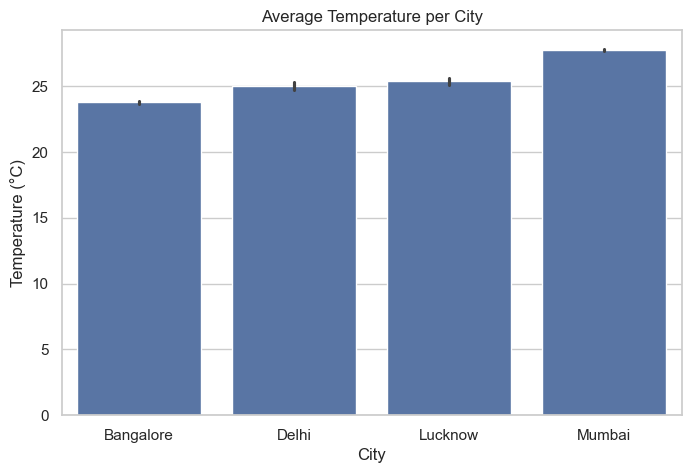

In [46]:
# Average temperature per city
plt.figure(figsize=(8,5))
sns.barplot(
    x="city",
    y="tavg",
    data=final_dataset,
    order=final_dataset.groupby("city")["tavg"].mean().sort_values().index
)
plt.title("Average Temperature per City")
plt.ylabel("Temperature (°C)")
plt.xlabel("City")
plt.show()

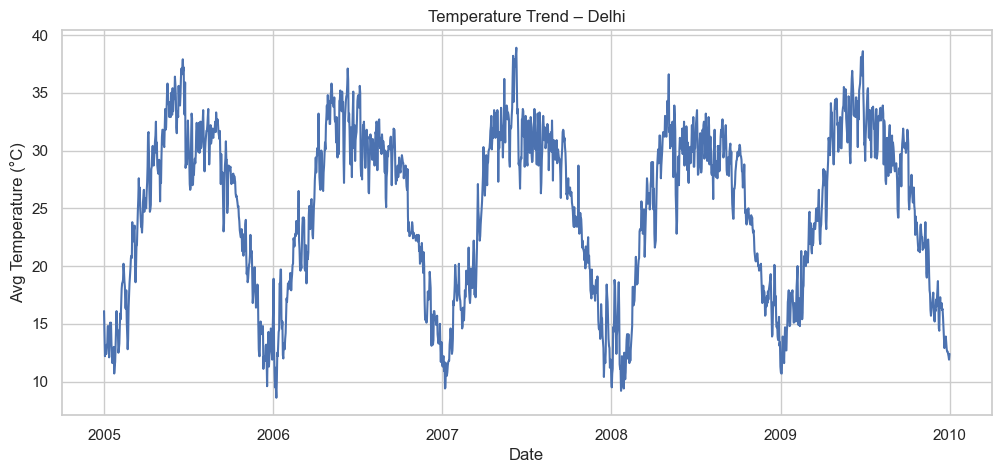

In [47]:
# Temperature trends over time
city_data = final_dataset[final_dataset["city"] == "Delhi"]

plt.figure(figsize=(12,5))
plt.plot(city_data["date"], city_data["tavg"], label="Avg Temp")
plt.title("Temperature Trend – Delhi")
plt.xlabel("Date")
plt.ylabel("Avg Temperature (°C)")
plt.show()

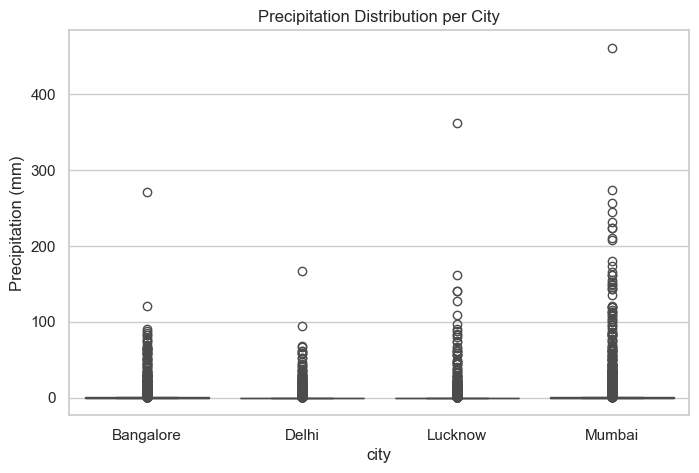

In [48]:
# Precipitation analysis
plt.figure(figsize=(8,5))
sns.boxplot(x="city", y="prcp", data=final_dataset)
plt.title("Precipitation Distribution per City")
plt.ylabel("Precipitation (mm)")
plt.show()

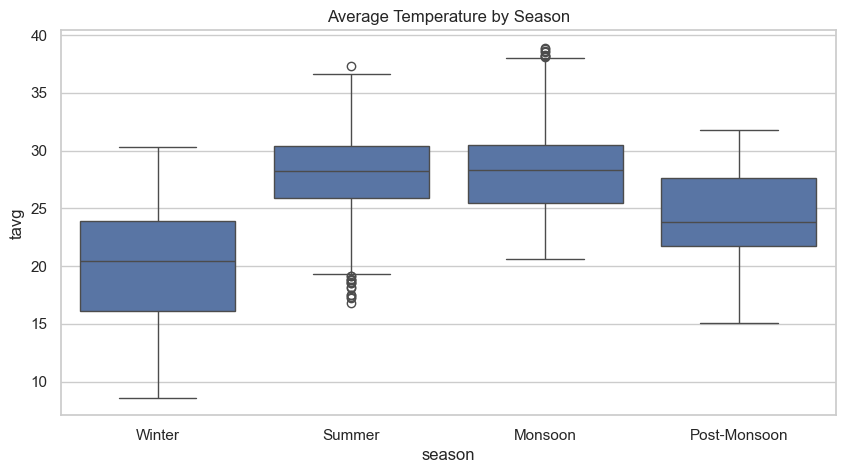

In [49]:
# Seasonal analysis
plt.figure(figsize=(10,5))
sns.boxplot(x="season", y="tavg", data=final_dataset)
plt.title("Average Temperature by Season")
plt.show()

C:\Users\Laxmi\AppData\Local\Temp\ipykernel_15824\3484840100.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="city", y="prcp", hue="season", data=final_dataset, ci=None)


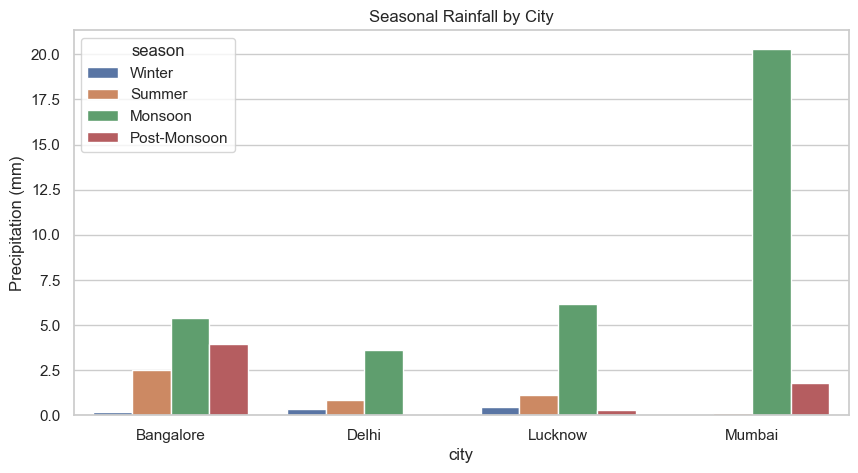

In [50]:
# Seasonal analysis
plt.figure(figsize=(10,5))
sns.barplot(x="city", y="prcp", hue="season", data=final_dataset, ci=None)
plt.title("Seasonal Rainfall by City")
plt.ylabel("Precipitation (mm)")
plt.show()